<a href="https://colab.research.google.com/github/sujoy10x/IITKGP-AI-ML/blob/dev/IITKGP_AI_ML_Module_2_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 2 Assignment**
### Optimization, Regularization, and Sequential Deep Learning

Executive Post Graduate Certificate in Applied AI & Machine Learning


Department of Artificial Intelligence, IIT Kharagpur | upGrad



---


# Part 1: Optimization Algorithms & Regularization Techniques [40 Marks]

##### **Dataset:** [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)
Bike Rental Demand Forecasting using PyTorch
---


---
## Task 0 - Environment Setup [Provided / 0 Marks]

The following cell installs required dependencies for Part 1.


In [ ]:
import os
import sys

!{sys.executable} -m pip install -q ucimlrepo scikit-learn torch numpy pandas matplotlib


## Task 1: Setup, Reproducibility & Data Preparation [8 Marks]


### 1.1 Library Imports & Setting Random Seeds (Q1) [1 Mark]

Q1: Import all required libraries and implement a seed initialization function for reproducible results under a fixed environment.

**Libraries to import:**
- `os`, `random`
- `numpy` as `np`, `pandas` as `pd`
- `matplotlib.pyplot` as `plt`
- `from IPython.display import display`
- `torch`, `torch.nn` as `nn`, `torch.optim` as `optim`
- `torch.utils.data`: `DataLoader`, `TensorDataset`
- `sklearn.model_selection`: `train_test_split`
- `sklearn.preprocessing`: `StandardScaler`
- `sklearn.metrics`: `mean_squared_error`, `r2_score`
- `from ucimlrepo import fetch_ucirepo`

**Seed function - `set_seed(seed=42)` must set:**
- `random.seed(seed)`
- `os.environ['PYTHONHASHSEED'] = str(seed)`
- `np.random.seed(seed)`
- `torch.manual_seed(seed)`
- When CUDA is available: `torch.cuda.manual_seed(seed)`, `torch.cuda.manual_seed_all(seed)`, `torch.backends.cudnn.deterministic = True`, `torch.backends.cudnn.benchmark = False`

Call `set_seed(42)` and configure the compute device:
```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```


In [ ]:
### YOUR CODE STARTS HERE ###

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

### YOUR CODE ENDS HERE ###

Device: cuda


### 1.2 Loading and Inspecting the Data (Q2) [3 Marks]

Q2: Fetch and load the Bike Sharing dataset using `ucimlrepo` (ID = 275) from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), inspect features, targets, metadata, and variables. Check for missing values and duplicates.

**Instructions:**
1. Fetch the dataset using `fetch_ucirepo(id=275)`:
   ```python
   bike = fetch_ucirepo(id=275)
   ```
2. Extract the features (`X`), targets (`y`), and the original DataFrame (`df`).
3. Print the dataset metadata and variable information.
4. Display the dataset shape using `df.shape` and preview the first 5 rows using `df.head()`.
5. Check for missing values across all columns using `df.isnull().sum()` and duplicate rows using `df.duplicated().sum()`.

**Expected Output:**
- Dataset shape: `(17379, 17)` (features: `(17379, 13)`, targets: `(17379, 1)`)
- 0 missing values across all columns
- 0 duplicate rows


In [ ]:
### YOUR CODE STARTS HERE ###

bike = fetch_ucirepo(id=275)
X = bike.data.features
y = bike.data.targets
df = bike.data.original.copy()

print('Metadata:')
print(bike.metadata)
print('\nVariables:')
display(bike.variables)
print('Shape:', df.shape)
display(df.head())
print('\nMissing values:')
display(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

### YOUR CODE ENDS HERE ###


Metadata:
{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue':

,name,role,type,demographic,description,units,missing_values
0,instant,ID,Integer,None,record index,None,no
1,dteday,Feature,Date,None,date,None,no
2,season,Feature,Categorical,None,"1:winter, 2:spring, 3:summer, 4:fall",None,no
3,yr,Feature,Categorical,None,"year (0: 2011, 1: 2012)",None,no
4,mnth,Feature,Categorical,None,month (1 to 12),None,no
5,hr,Feature,Categorical,None,hour (0 to 23),None,no
6,holiday,Feature,Binary,None,weather day is holiday or not (extracted from ...,None,no
7,weekday,Feature,Categorical,None,day of the week,None,no
8,workingday,Feature,Binary,None,"if day is neither weekend nor holiday is 1, ot...",None,no
9,weathersit,Feature,Categorical,None,"- 1: Clear, Few clouds, Partly cloudy, Partly ...",None,no


Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



Missing values:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Duplicate rows: 0


### 1.3 Feature Preprocessing & One-Hot Encoding (Q3) [2 Marks]

Q3: Remove redundant/leakage columns and apply one-hot encoding to categorical features.

**Columns to drop:** `drop_cols = ['instant', 'dteday', 'casual', 'registered']`
- `instant` - arbitrary record index, not a predictive feature.
- `dteday` - date string already captured by `season`/`yr`/`mnth`/`weekday`/`workingday`.
- `casual` and `registered` - direct subcomponents of the target `cnt` (`cnt = casual + registered`), keeping them causes target leakage.

Drop these columns from `df`: `df_clean = df.drop(columns=drop_cols)`.

**Categorical columns to one-hot encode:** `cat_features = ['season', 'yr', 'mnth', 'hr', 'weekday', 'weathersit']`

Apply: `pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=float)` to avoid the dummy variable trap.

Display the resulting DataFrame shape and preview `df_encoded.head()`.

**Expected Output:** Dataset shape after encoding: `(17379, 54)` - 53 features + 1 target `cnt`.


In [ ]:
### YOUR CODE STARTS HERE ###

drop_cols = ['instant', 'dteday', 'casual', 'registered']
cat_features = ['season', 'yr', 'mnth', 'hr', 'weekday', 'weathersit']
df_clean = df.drop(columns=drop_cols)
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=float)
print('Encoded shape:', df_encoded.shape)
display(df_encoded.head())

### YOUR CODE ENDS HERE ###


Encoded shape: (17379, 54)


,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,...,hr_23,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3,weathersit_4
0,0,0,0.24,0.2879,0.81,0.0,16,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,0,0.22,0.2727,0.80,0.0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,0,0.22,0.2727,0.80,0.0,32,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,0,0.24,0.2879,0.75,0.0,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0.24,0.2879,0.75,0.0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 1.4 Dataset Splitting & Standardization (Q4) [2 Marks]

Q4: Split the dataset into Train/Val/Test sets, standardize features, and create PyTorch DataLoaders.

**Steps:**
1. Separate features and target:
   - `X = df_encoded.drop(columns=['cnt']).values`
   - `y = df_encoded['cnt'].values` reshaped to `(-1, 1)`
2. First split - 70% Train, 30% Temp: `train_test_split(X, y, test_size=0.30, random_state=42)`.
3. Second split - split Temp equally into 15% Val and 15% Test: `train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)`.
4. Fit `StandardScaler()` on `X_train` only, then transform `X_train`, `X_val`, and `X_test`. **Do NOT scale the target `y`.**
5. Convert all arrays to `torch.float32` tensors (y shaped as `(-1, 1)`).
6. Create `TensorDataset` and `DataLoader` objects with `batch_size=64`:
   - `train_loader` (`shuffle=True`)
   - `val_loader` (`shuffle=False`)
   - `test_loader` (`shuffle=False`)

**Expected Output:**
- Train: `(12165, 53)`, Val: `(2607, 53)`, Test: `(2607, 53)`
- Target shapes: `(12165, 1)`, `(2607, 1)`, `(2607, 1)`


In [ ]:
### YOUR CODE STARTS HERE ###

X = df_encoded.drop(columns=['cnt']).values
y = df_encoded['cnt'].values.reshape(-1, 1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)
print('Train:', X_train_scaled.shape, y_train.shape)
print('Val:', X_val_scaled.shape, y_val.shape)
print('Test:', X_test_scaled.shape, y_test.shape)

### YOUR CODE ENDS HERE ###


Train: (12165, 53) (12165, 1)
Val: (2607, 53) (2607, 1)
Test: (2607, 53) (2607, 1)


## Task 2: Neural Network Architecture & Training Loop [10 Marks]


### 2.1 Model Architecture - `BikeRentalNN` (Q5) [4 Marks]

Q5: Design a 4-hidden-layer PyTorch neural network class `BikeRentalNN` for regression.

**Architecture:** `input_dim → 1024 → 512 → 128 → 64 → 1`

| Layer | Details |
|---|---|
| Layer 1 | `Linear(input_dim, 1024)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 2 | `Linear(1024, 512)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 3 | `Linear(512, 128)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 4 | `Linear(128, 64)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Output | `Linear(64, 1)` - Linear activation for regression |

**Constructor:** `__init__(self, input_dim: int, dropout_rate: float = 0.0, use_dropout: bool = False)`
- Build all layers using `nn.Sequential` and store as `self.net`.
- If `use_dropout` is `True`, insert `nn.Dropout(dropout_rate)` after each ReLU.

**Forward:** `forward(self, x)` - pass input through `self.net` and return output.

Store the feature count as `input_features` (e.g. `input_features = X_train_scaled.shape[1]`) — **Q7 and Q10 reuse this name**. Instantiate a sample model with `BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False)` and display its structure. Calculate total trainable parameters: `sum(p.numel() for p in model.parameters() if p.requires_grad)`.

**Expected Output:** Total Trainable Parameters: `654,081`.


In [ ]:
### YOUR CODE STARTS HERE ###

class BikeRentalNN(nn.Module):
    def __init__(self, input_dim: int, dropout_rate: float = 0.0, use_dropout: bool = False):
        super().__init__()
        layers = [nn.Linear(input_dim, 1024), nn.ReLU()]
        if use_dropout: layers.append(nn.Dropout(dropout_rate))
        layers += [nn.Linear(1024, 512), nn.ReLU()]
        if use_dropout: layers.append(nn.Dropout(dropout_rate))
        layers += [nn.Linear(512, 128), nn.ReLU()]
        if use_dropout: layers.append(nn.Dropout(dropout_rate))
        layers += [nn.Linear(128, 64), nn.ReLU()]
        if use_dropout: layers.append(nn.Dropout(dropout_rate))
        layers += [nn.Linear(64, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

input_features = X_train_scaled.shape[1]
model = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)
print(model)
print('Total Trainable Parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

### YOUR CODE ENDS HERE ###


BikeRentalNN(
  (net): Sequential(
    (0): Linear(in_features=53, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total Trainable Parameters: 654081


### 2.2 Training & Evaluation Functions (Q6) [6 Marks]

Q6: Implement `train_regression_model` and `evaluate_regression_model` functions.

**Function 1 - `train_regression_model(model, optimizer, criterion, train_loader, val_loader, epochs=50, device='cpu', print_interval=10)`:**
1. Loop over epochs 1 to `epochs`.
2. **Training phase** (`model.train()`): For each batch - forward pass → compute loss → `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()` → accumulate running train loss.
3. **Validation phase** (`model.eval()` with `torch.no_grad()`): For each val batch - compute val loss → accumulate running val loss.
4. Calculate average train/val MSE per epoch. Print progress every `print_interval` epochs.
5. Return `(train_loss_history, val_loss_history)` - lists of per-epoch average losses.

**Function 2 - `evaluate_regression_model(model, loader, device='cpu')`:**
1. Set `model.eval()` with `torch.no_grad()`. Collect all predictions and true targets as numpy arrays.
2. Clip negative predictions to zero: `preds_clipped = np.clip(preds_raw, a_min=0, a_max=None)` (bike counts cannot be negative).
3. Compute: MSE via `mean_squared_error()`, RMSE via `np.sqrt(mse)`, R² via `r2_score()`.
4. Return `(mse, rmse, r2, preds_clipped, targets_raw)`. Raw predictions are retained internally as `preds_raw`; metrics and returned predictions use non-negative `preds_clipped`.


In [ ]:
### YOUR CODE STARTS HERE ###

def train_regression_model(model, optimizer, criterion, train_loader, val_loader, epochs=50, device='cpu', print_interval=10):
    train_loss_history, val_loss_history = [], []
    for epoch in range(1, epochs + 1):
        model.train(); running_train = 0.0; n_train = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            running_train += loss.item() * xb.size(0); n_train += xb.size(0)
        model.eval(); running_val = 0.0; n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(model(xb), yb)
                running_val += loss.item() * xb.size(0); n_val += xb.size(0)
        train_loss = running_train / n_train; val_loss = running_val / n_val
        train_loss_history.append(train_loss); val_loss_history.append(val_loss)
        if epoch == 1 or epoch % print_interval == 0 or epoch == epochs:
            print(f'Epoch {epoch:03d}/{epochs}: Train MSE={train_loss:.4f}, Val MSE={val_loss:.4f}')
    return train_loss_history, val_loss_history

def evaluate_regression_model(model, loader, device='cpu'):
    model.eval(); preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device)).detach().cpu().numpy()
            preds.append(out); targets.append(yb.numpy())
    preds_raw = np.concatenate(preds, axis=0).reshape(-1)
    targets_raw = np.concatenate(targets, axis=0).reshape(-1)
    preds_clipped = np.clip(preds_raw, a_min=0, a_max=None)
    mse = mean_squared_error(targets_raw, preds_clipped)
    rmse = np.sqrt(mse); r2 = r2_score(targets_raw, preds_clipped)
    return mse, rmse, r2, preds_clipped, targets_raw


### YOUR CODE ENDS HERE ###


## Task 3: Multi-Optimizer Training & Convergence Comparison [10 Marks]


### 3.1 Training with AdaGrad, RMSprop, and Adam (Q7) [6 Marks]

Q7: Train three separate unregularized `BikeRentalNN` models using three adaptive optimizers.

**Shared hyperparameters:**
- `epochs = 50`
- `learning_rate = 0.001`
- `criterion = nn.MSELoss()`
- All models: `use_dropout=False`, no weight decay

**Three models to train:**

| Model | Optimizer | Key Parameters |
|---|---|---|
| Model 1 | `optim.Adagrad` | `lr=0.001` |
| Model 2 | `optim.RMSprop` | `lr=0.001, alpha=0.99` |
| Model 3 | `optim.Adam` | `lr=0.001, betas=(0.9, 0.999)` |

**Steps for each model:**
1. Call `set_seed(42)` **immediately before instantiating each model**, so all three optimizers start from identical weights and the Q9 comparison is fair.
2. Instantiate `BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)`.
3. Create the optimizer with the specified hyperparameters.
4. Train using `train_regression_model()` for 50 epochs.
5. Store the train and validation loss histories.


In [ ]:
### YOUR CODE STARTS HERE ###
epochs = 50; learning_rate = 0.001; criterion = nn.MSELoss()
models_dict, histories = {}, {}
for name in ['AdaGrad', 'RMSprop', 'Adam']:
    set_seed(42)
    m = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)
    if name == 'AdaGrad': opt = optim.Adagrad(m.parameters(), lr=learning_rate)
    elif name == 'RMSprop': opt = optim.RMSprop(m.parameters(), lr=learning_rate, alpha=0.99)
    else: opt = optim.Adam(m.parameters(), lr=learning_rate, betas=(0.9, 0.999))
    tr, va = train_regression_model(m, opt, criterion, train_loader, val_loader, epochs=epochs, device=device)
    models_dict[name] = m; histories[name] = (tr, va)
    print(name, 'training complete')


### YOUR CODE ENDS HERE ###


Epoch 001/50: Train MSE=28001.5046, Val MSE=15884.1735
Epoch 010/50: Train MSE=6873.3159, Val MSE=6462.5321
Epoch 020/50: Train MSE=4466.8340, Val MSE=4332.7207
Epoch 030/50: Train MSE=3146.3965, Val MSE=3238.7122
Epoch 040/50: Train MSE=2674.8688, Val MSE=2796.0132
Epoch 050/50: Train MSE=2434.7046, Val MSE=2582.9908
AdaGrad training complete
Epoch 001/50: Train MSE=9852.2116, Val MSE=4985.1666
Epoch 010/50: Train MSE=1710.6138, Val MSE=1994.7855
Epoch 020/50: Train MSE=1254.8570, Val MSE=1668.6701
Epoch 030/50: Train MSE=952.9068, Val MSE=5023.8415
Epoch 040/50: Train MSE=723.6447, Val MSE=2257.6849
Epoch 050/50: Train MSE=605.7119, Val MSE=2200.9063
RMSprop training complete
Epoch 001/50: Train MSE=16601.9586, Val MSE=6007.6937
Epoch 010/50: Train MSE=1392.3736, Val MSE=1566.9852
Epoch 020/50: Train MSE=1006.6230, Val MSE=1575.9689
Epoch 030/50: Train MSE=754.0726, Val MSE=1629.6366
Epoch 040/50: Train MSE=555.3317, Val MSE=1739.2501
Epoch 050/50: Train MSE=473.3035, Val MSE=1784.77

### 3.2 Plotting Loss Convergence Curves (Q8) [2 Marks]

Q8: Plot convergence curves comparing Training Loss and Validation Loss vs Epochs for each optimizer.

**Steps:**
1. Create a `1×3` subplot grid using `plt.subplots(1, 3, figsize=(18, 5), sharey=True)`.
2. For each optimizer (AdaGrad, RMSprop, Adam) on its own subplot:
   - Plot Epoch (1–50) vs Train Loss and Val Loss as two separate lines.
3. Add subplot titles (optimizer name), axis labels (`'Epoch'`, `'Loss (MSE)'`), legends (`'Train Loss'`, `'Val Loss'`), and grid lines.
4. `plt.tight_layout()` and `plt.show()`.


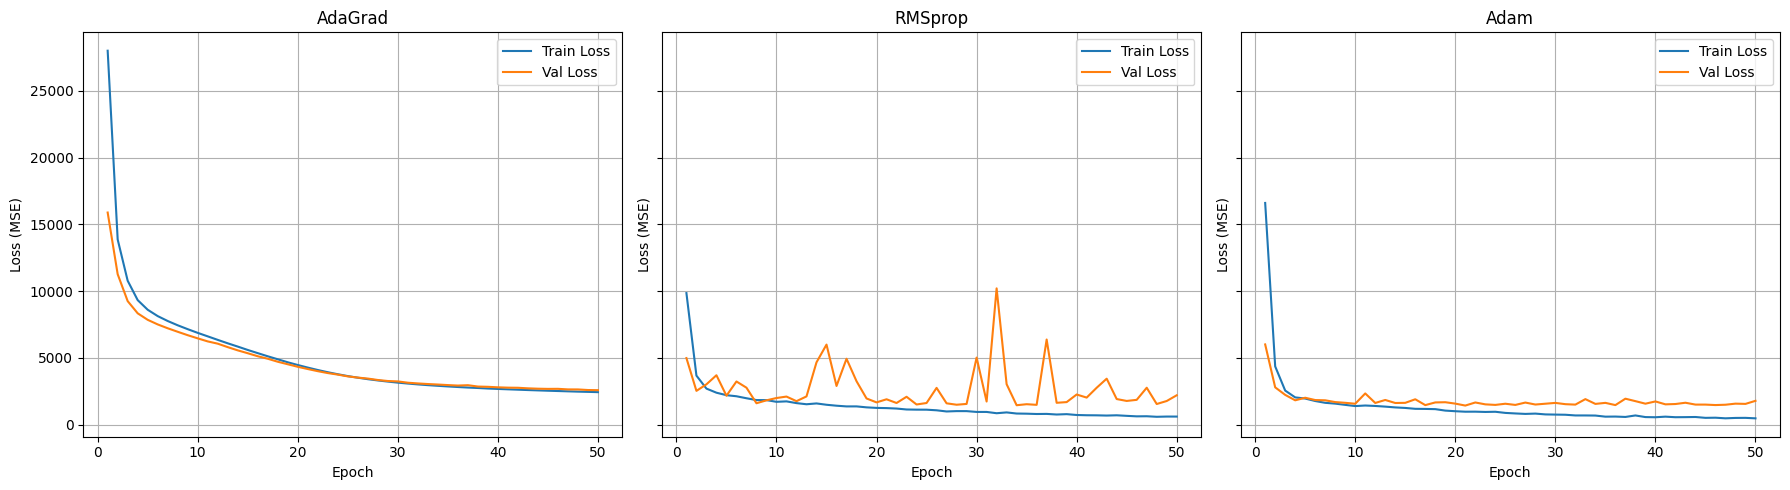

In [ ]:
### YOUR CODE STARTS HERE ###

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, ['AdaGrad', 'RMSprop', 'Adam']):
    tr, va = histories[name]; ax.plot(range(1, 51), tr, label='Train Loss'); ax.plot(range(1, 51), va, label='Val Loss')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE)'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### YOUR CODE ENDS HERE ###


### 3.3 Optimizer Validation Performance Summary & Selection (Q9) [2 Marks]

Q9: Compare validation performance of all three optimizers and select the best one.

**Steps:**
1. Evaluate all three models (AdaGrad, RMSprop, Adam) on `val_loader` using `evaluate_regression_model()`.
2. Construct a `pd.DataFrame` with columns: `['Optimizer', 'Validation MSE', 'Validation RMSE', 'Validation R² Score', 'Final Val Loss']`.
3. Sort the DataFrame by Validation R² Score descending and display it.
4. Extract the best optimizer name:
   ```python
   best_optimizer_name = df_val_summary.iloc[0]['Optimizer']
   ```
5. Print the selected best optimizer.


In [ ]:
### YOUR CODE STARTS HERE ###

rows=[]
for name, m in models_dict.items():
    mse, rmse, r2, _, _ = evaluate_regression_model(m, val_loader, device)
    rows.append({'Optimizer': name, 'Validation MSE': mse, 'Validation RMSE': rmse, 'Validation R² Score': r2, 'Final Val Loss': histories[name][1][-1]})
df_val_summary = pd.DataFrame(rows).sort_values('Validation R² Score', ascending=False).reset_index(drop=True)
display(df_val_summary)
best_optimizer_name = df_val_summary.iloc[0]['Optimizer']
print('Best optimizer:', best_optimizer_name)


### YOUR CODE ENDS HERE ###


,Optimizer,Validation MSE,Validation RMSE,Validation R² Score,Final Val Loss
0,Adam,1784.770996,42.246550,0.944868,1784.770961
1,RMSprop,2200.906250,46.913817,0.932013,2200.906266
2,AdaGrad,2582.990723,50.823132,0.920210,2582.990826


Best optimizer: Adam


## Task 4: Regularization Study (Overfitting Analysis) [6 Marks]


### 4.1 Regularization Comparison & Generalization Gap (Q10) [6 Marks]

Q10: Train a regularized model using the winning optimizer selected in Q9 using `best_optimizer_name` and compare with the unregularized version.

**Steps:**
0. Call `set_seed(42)` before instantiating the model, so the regularized run starts from the same initialization as the unregularized baseline.
1. Instantiate a regularized model:
   ```python
   BikeRentalNN(input_dim=input_features, dropout_rate=0.25, use_dropout=True).to(device)
   ```
2. Store the two regularization settings as `dropout_rate = 0.25` and `l2_weight_decay = 1e-4` — **Q11 reuses both names**. Initialize the optimizer corresponding to `best_optimizer_name` with `weight_decay=l2_weight_decay`, `lr=0.001`.
3. Train the regularized model for `50 epochs` using `train_regression_model()`.
4. Plot a single comparative figure (`figsize=(11, 6.5)`) overlaying **4 curves** on the same axes:
   - Unregularized Train Loss
   - Unregularized Val Loss
   - Regularized Train Loss
   - Regularized Val Loss
5. Add title, axis labels, legend, and grid to visualize the generalization gap improvement.


Epoch 001/50: Train MSE=17836.1906, Val MSE=6233.9374
Epoch 010/50: Train MSE=3070.5799, Val MSE=1985.2902
Epoch 020/50: Train MSE=2898.2802, Val MSE=1810.8795
Epoch 030/50: Train MSE=2528.6473, Val MSE=2114.7689
Epoch 040/50: Train MSE=2361.6098, Val MSE=1493.8924
Epoch 050/50: Train MSE=2240.6758, Val MSE=1434.5530


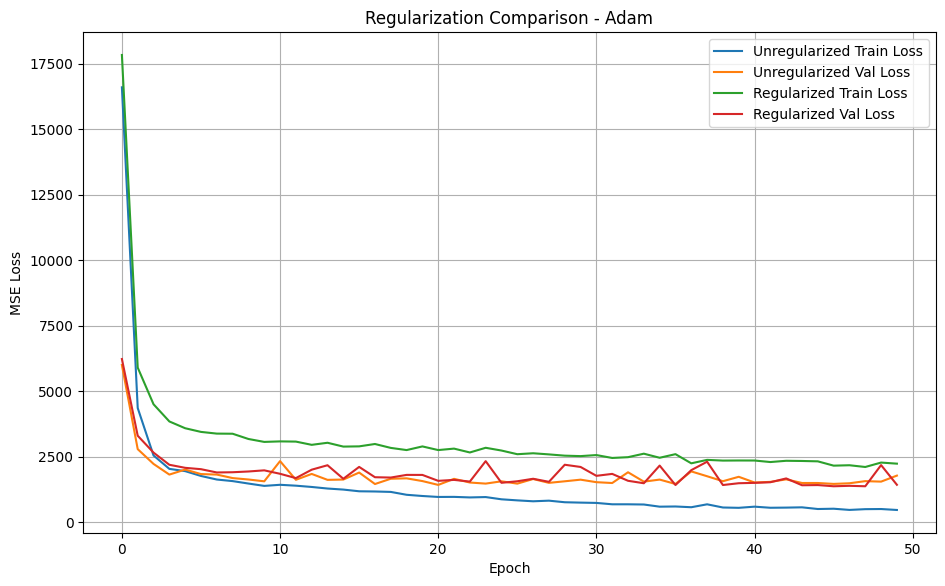

In [ ]:
### YOUR CODE STARTS HERE ###

set_seed(42)
dropout_rate = 0.25; l2_weight_decay = 1e-4
model_regularized = BikeRentalNN(input_dim=input_features, dropout_rate=dropout_rate, use_dropout=True).to(device)
if best_optimizer_name == 'AdaGrad': optimizer_regularized = optim.Adagrad(model_regularized.parameters(), lr=0.001, weight_decay=l2_weight_decay)
elif best_optimizer_name == 'RMSprop': optimizer_regularized = optim.RMSprop(model_regularized.parameters(), lr=0.001, alpha=0.99, weight_decay=l2_weight_decay)
else: optimizer_regularized = optim.Adam(model_regularized.parameters(), lr=0.001, betas=(0.9,0.999), weight_decay=l2_weight_decay)
train_reg, val_reg = train_regression_model(model_regularized, optimizer_regularized, criterion, train_loader, val_loader, epochs=50, device=device)
train_unreg, val_unreg = histories[best_optimizer_name]
plt.figure(figsize=(11,6.5)); plt.plot(train_unreg,label='Unregularized Train Loss'); plt.plot(val_unreg,label='Unregularized Val Loss'); plt.plot(train_reg,label='Regularized Train Loss'); plt.plot(val_reg,label='Regularized Val Loss'); plt.title(f'Regularization Comparison - {best_optimizer_name}'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(True); plt.show()


### YOUR CODE ENDS HERE ###


## Task 5: Test Set Evaluation & Prediction Visualizations [6 Marks]


### 5.1 Test Performance Metrics (Q11) [4 Marks]

Q11: Evaluate both model configurations (Unregularized vs Regularized with `best_optimizer_name`) on the unseen Test set.

**Steps:**
1. Evaluate the **Unregularized** model on `test_loader` using `evaluate_regression_model()`.
2. Evaluate the **Regularized** model on `test_loader` using `evaluate_regression_model()`.
3. Construct a `pd.DataFrame` with columns: `['Model', 'Regularization', 'Test MSE', 'Test RMSE', 'Test R² Score']`.
   - Row 1: `Unregularized {best_optimizer_name}` - Regularization = `None (Dropout=0, L2=0)`
   - Row 2: `Regularized {best_optimizer_name}` - Regularization = `Dropout=0.25, L2=0.0001` (formatted from your `dropout_rate` and `l2_weight_decay` variables)
4. Display the summary DataFrame.

> **Names Q12 reuses:** keep the predictions returned by `evaluate_regression_model()` as `preds_unreg` and `preds_reg`, and the returned ground-truth array as `targets_test`.


In [ ]:
### YOUR CODE STARTS HERE ###

mse_u, rmse_u, r2_u, preds_unreg, targets_test = evaluate_regression_model(models_dict[best_optimizer_name], test_loader, device)
mse_r, rmse_r, r2_r, preds_reg, _ = evaluate_regression_model(model_regularized, test_loader, device)
test_summary = pd.DataFrame([{'Model': f'Unregularized {best_optimizer_name}', 'Regularization':'None (Dropout=0, L2=0)','Test MSE':mse_u,'Test RMSE':rmse_u,'Test R² Score':r2_u},{'Model':f'Regularized {best_optimizer_name}','Regularization':f'Dropout={dropout_rate}, L2={l2_weight_decay}','Test MSE':mse_r,'Test RMSE':rmse_r,'Test R² Score':r2_r}])
display(test_summary)


### YOUR CODE ENDS HERE ###


,Model,Regularization,Test MSE,Test RMSE,Test R² Score
0,Unregularized Adam,"None (Dropout=0, L2=0)",2087.688965,45.691235,0.932227
1,Regularized Adam,"Dropout=0.25, L2=0.0001",1670.825439,40.875732,0.945760


### 5.2 Prediction Visualizations & Scatter Plot (Q12) [2 Marks]

Q12: Create a scatter plot of True vs Predicted bike rental counts on the test set for the best model.

> **Model Selection Protocol:** The winning model is selected based on **Validation R² performance** (comparing the regularized model against the unregularized model on `val_loader`), and then visualized on the test set.

**Steps:**
1. Determine the best model configuration based on validation R² score.
2. Compute absolute prediction errors on the test set: `abs_errors = np.abs(targets_test - best_preds)`.
3. Create a scatter plot (`plt.figure(figsize=(9, 7))`) with:
   - x-axis: `targets_test` (Actual Bike Demand)
   - y-axis: `best_preds` (Predicted Bike Demand)
   - Color points by `abs_errors` using `cmap='viridis'` and `alpha=0.6`
4. Draw the ideal reference line `y = x` as a red dashed line (`'r--'`) from 0 to `max_val = max(targets_test.max(), best_preds.max())`.
5. Add a colorbar for the error magnitude.
6. Label axes: `'Actual Bike Demand (cnt)'` (x-axis), `'Predicted Bike Demand (cnt)'` (y-axis).
7. Add title with the model name and Test R² score annotated, and enable grid lines.


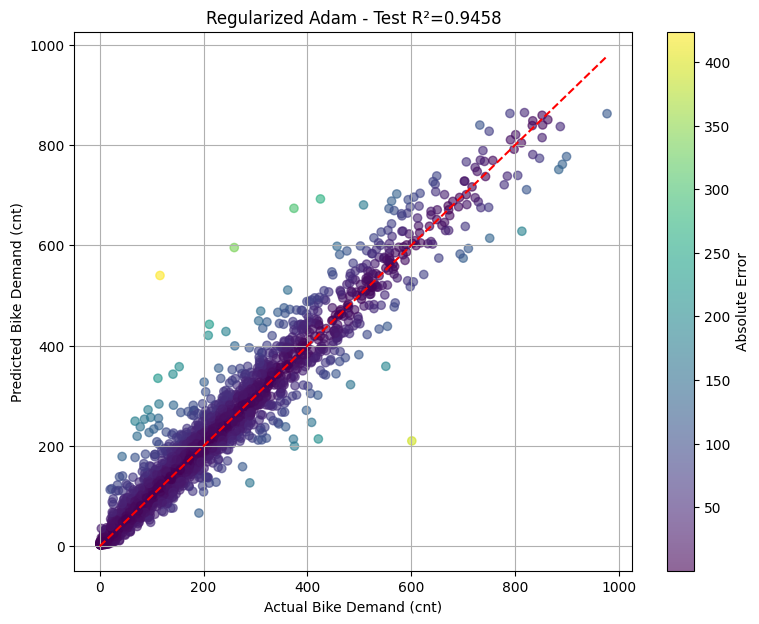

In [ ]:
### YOUR CODE STARTS HERE ###

val_u = evaluate_regression_model(models_dict[best_optimizer_name], val_loader, device)[2]
val_r = evaluate_regression_model(model_regularized, val_loader, device)[2]
if val_r > val_u: best_model_name = f'Regularized {best_optimizer_name}'; best_preds = preds_reg; best_test_r2 = r2_r
else: best_model_name = f'Unregularized {best_optimizer_name}'; best_preds = preds_unreg; best_test_r2 = r2_u
abs_errors = np.abs(targets_test - best_preds); plt.figure(figsize=(9,7)); sc=plt.scatter(targets_test,best_preds,c=abs_errors,cmap='viridis',alpha=0.6); max_val=max(targets_test.max(),best_preds.max()); plt.plot([0,max_val],[0,max_val],'r--'); plt.colorbar(sc,label='Absolute Error'); plt.xlabel('Actual Bike Demand (cnt)'); plt.ylabel('Predicted Bike Demand (cnt)'); plt.title(f'{best_model_name} - Test R²={best_test_r2:.4f}'); plt.grid(True); plt.show()


### YOUR CODE ENDS HERE ###


# Part 2: Video Action Recognition - Recurrent Models and CNN Fine-Tuning [60 Marks]

**Dataset:** [KTH Action Recognition Dataset](https://www.kaggle.com/datasets/vafaeii/kth-action-recognition-dataset)

In this part, you will build a video action classifier using deep convolutional features (ResNet-18) and recurrent models (RNN and LSTM). You will train recurrent heads on cached features, followed by fine-tuning the CNN backbone end-to-end.

> **GPU required.** Before running Part 2, switch the Colab runtime to a GPU: **Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU**. Stage-2 fine-tuning back-propagates through the CNN and is not feasible on CPU. Task 6 alone takes roughly 1.5-2 hours of GPU time, so run Part 2 in a single uninterrupted session.


---
## Task 0 - Imports and Setup [Provided / 0 Marks]

The following setup cells install dependencies, import libraries, configure directory paths, and set global hyperparameters for the video pipeline.


In [ ]:
import os
import sys

!{sys.executable} -m pip install -q opencv-python kagglehub numpy pandas matplotlib Pillow scikit-learn torch torchvision


In [ ]:
import gc
import json
import random
import re
import time
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from sklearn.metrics import precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms


## Global configuration


In [ ]:
SEED = 42

CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
NUM_CLASSES = len(CLASSES)

# Subject-wise split (no subject appears in more than one split).
TRAIN_SUBJECTS = set(range(1, 17))    # 1-16
VAL_SUBJECTS   = set(range(17, 21))   # 17-20
TEST_SUBJECTS  = set(range(21, 26))   # 21-25

# Clip sampling
CLIP_LEN   = 16       # Temporal samples per video
# Increment whenever frame extraction/sampling logic or cache format changes.
# This invalidates previously generated cached frames.
SAMPLING_VERSION = 2
IMAGE_SIZE = 224      # frames are cached already resized to 224x224

# Recurrent head
HIDDEN_SIZE = 64  # Hidden dimension for RNN/LSTM
NUM_LAYERS  = 1
DROPOUT     = 0.3
FEATURE_DIM = 512   # ResNet-18 global-average-pooled output

# Optimisation (shared by both stages)
OPTIMIZER_NAME          = "Adam"
WEIGHT_DECAY            = 1e-4
GRADIENT_CLIP_NORM      = 1.0
EARLY_STOPPING_PATIENCE = 5

# Stage 1 - trains on precomputed features, so batches can be large.
STAGE1_BATCH_SIZE = 32
STAGE1_MAX_EPOCHS = 50
STAGE1_LR         = 1e-3

# Stage 2 - backpropagates through the CNN, so the GPU batch is kept safe.
STAGE2_BATCH_SIZE        = 4
STAGE2_GRAD_ACCUMULATION = 4    # effective batch = 4 x 4 = 16
STAGE2_MAX_EPOCHS        = 50
STAGE2_LR                = 1e-4

# Paths
PROJECT_DIR  = Path.cwd()
DATASET_DIR  = PROJECT_DIR / "dataset"
CACHE_DIR    = DATASET_DIR / "cached_frames"
FEATURE_DIR  = DATASET_DIR / "features"
MODEL_DIR    = PROJECT_DIR / "models"

for directory in (DATASET_DIR, CACHE_DIR, FEATURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # Safe for cross-platform Jupyter execution


def set_seed(seed=SEED):
    """
    Sets random seeds across Python, NumPy, and PyTorch (CPU & CUDA)
    for reproducible results under a fixed environment.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

print(f"Device       : {DEVICE}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Classes      : {NUM_CLASSES} -> {CLASSES}")
print(f"Clip length  : {CLIP_LEN} frames @ {IMAGE_SIZE}x{IMAGE_SIZE}")


Device       : cuda
Workers      : 0
Classes      : 6 -> ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']
Clip length  : 16 frames @ 224x224


## Task 1 - Dataset Download [Provided / 0 Marks]

The following function downloads and verifies the raw video files for all 6 action classes.


In [ ]:
DATASET_PATH = None

# KaggleHub
if DATASET_PATH is None or not list(DATASET_PATH.rglob("*.avi")):
    try:
        import kagglehub
        path = Path(kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset"))
        if list(path.rglob("*.avi")):
            DATASET_PATH = path
            print("Successfully loaded dataset from KaggleHub!")
    except Exception as e:
        print(f"KaggleHub download notice: {e}")

# Fallback: Local raw directory
if DATASET_PATH is None or not list(DATASET_PATH.rglob("*.avi")):
    local_raw = Path("./dataset/raw")
    if local_raw.exists() and list(local_raw.rglob("*.avi")):
        DATASET_PATH = local_raw
        print(f"Using local raw dataset from: {DATASET_PATH}")
    else:
        raise RuntimeError("Could not locate KTH dataset files.")

VIDEO_FILES = sorted(DATASET_PATH.rglob("*.avi"))

print("Dataset path :", DATASET_PATH)
print("Videos found :", len(VIDEO_FILES))
print("Example      :", VIDEO_FILES[0].name)


100%|██████████| 1.07G/1.07G [00:12<00:00, 92.6MB/s]

Extracting files...


Successfully loaded dataset from KaggleHub!
Dataset path : /root/.cache/kagglehub/datasets/vafaeii/kth-action-recognition-dataset/versions/234
Videos found : 599
Example      : person01_boxing_d1_uncomp.avi


## Task 2 - Video Preprocessing Pipeline [Provided / 0 Marks]

The metadata extraction (Task 2.1) and frame decoding & caching (Task 2.2) are provided below.


### 2.1 - Metadata Parsing & Subject-Wise Split [Provided / 0 Marks]

The KTH dataset ships `00sequences.txt`, which splits each long take into multiple active sub-sequences. The cell below parses this manifest, pairs it with filename metadata, and assigns subject-wise splits (Train: 1-16, Val: 17-20, Test: 21-25).


In [ ]:
VIDEO_PATTERN = re.compile(r"person(\d+)_([A-Za-z]+)_(d\d)_uncomp\.avi$", re.IGNORECASE)

def parse_00sequences(filepath):
    """Parses 00sequences.txt into a dict mapping clean video stems to list of (start, end) tuples."""
    sequences = {}
    pattern = re.compile(r"^(person\d+_\w+_\w+)\s+frames\s+(.+)$")
    if not os.path.exists(filepath):
        return sequences

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            match = pattern.match(line)
            if match:
                stem, ranges_str = match.groups()
                ranges = []
                for r in ranges_str.split(","):
                    r = r.strip()
                    if "-" in r:
                        parts = r.split("-")
                        ranges.append((int(parts[0]), int(parts[1])))
                if ranges:
                    sequences[stem] = ranges
    return sequences


# Locate and parse 00sequences.txt
seq_file = DATASET_PATH / "00sequences.txt"
if not seq_file.exists():
    seq_files = list(DATASET_PATH.glob("**/00sequences.txt")) or list(Path(".").glob("**/00sequences.txt"))
    if seq_files:
        seq_file = seq_files[0]

SEQUENCE_RANGES = parse_00sequences(seq_file)
print(f"Loaded active sequence annotations for {len(SEQUENCE_RANGES)} video files from {seq_file.name}")


def assign_split(subject):
    if subject in TRAIN_SUBJECTS:
        return "train"
    if subject in VAL_SUBJECTS:
        return "val"
    if subject in TEST_SUBJECTS:
        return "test"
    raise ValueError(f"Subject {subject} is not in any split.")


def build_video_dataframe(video_files):
    records = []
    for video_path in video_files:
        match = VIDEO_PATTERN.search(video_path.name)
        if match is None:
            continue

        subject = int(match.group(1))
        action = match.group(2).lower()
        if action not in CLASSES:
            continue

        scenario = match.group(3).lower()
        clean_stem = f"person{subject:02d}_{action}_{scenario}"
        seq_ranges = SEQUENCE_RANGES.get(clean_stem, [])

        if seq_ranges:
            for seq_idx, (start_f, end_f) in enumerate(seq_ranges):
                records.append({
                    "path": video_path,
                    "stem": f"{clean_stem}_seq{seq_idx}",
                    "raw_stem": clean_stem,
                    "seq_idx": seq_idx,
                    "start_frame": start_f,
                    "end_frame": end_f,
                    "subject": subject,
                    "action": action,
                    "scenario": scenario,
                    "label": CLASSES.index(action),
                    "split": assign_split(subject),
                })
        else:
            records.append({
                "path": video_path,
                "stem": f"{clean_stem}_seq0",
                "raw_stem": clean_stem,
                "seq_idx": 0,
                "start_frame": 1,
                "end_frame": -1,
                "subject": subject,
                "action": action,
                "scenario": scenario,
                "label": CLASSES.index(action),
                "split": assign_split(subject),
            })

    dataframe = pd.DataFrame(records)
    if dataframe.empty:
        raise RuntimeError("No valid KTH videos could be parsed.")
    return dataframe


video_df = build_video_dataframe(VIDEO_FILES)

# Assert split isolation
assert not (TRAIN_SUBJECTS & VAL_SUBJECTS)
assert not (TRAIN_SUBJECTS & TEST_SUBJECTS)
assert not (VAL_SUBJECTS & TEST_SUBJECTS)
assert video_df["stem"].is_unique, "Clip cache folder names must be unique."

EXPECTED_CLIP_COUNT = 2391  # KTH active sub-sequences listed in 00sequences.txt

n_subjects = video_df["subject"].nunique()
print(f"Expanded dataset to {len(video_df)} clip samples across {n_subjects} subjects.\n")

if len(video_df) != EXPECTED_CLIP_COUNT:
    print(
        f"WARNING: built {len(video_df)} clips but expected {EXPECTED_CLIP_COUNT}.\n"
        f"         Active-sequence annotations parsed: {len(SEQUENCE_RANGES)}.\n"
        "         If that count is 0, 00sequences.txt was not found and each video\n"
        "         contributes a single uniform clip instead of its sub-sequences.\n"
        "         Split sizes and feature-tensor shapes will then differ from the\n"
        "         documented 1528 / 384 / 479.\n"
    )

print(video_df.groupby(["split", "action"]).size().unstack(fill_value=0))
print()
print(video_df["split"].value_counts().rename("clip_samples").to_frame())


Loaded active sequence annotations for 599 video files from 00sequences.txt
Expanded dataset to 2391 clip samples across 25 subjects.

action  boxing  handclapping  handwaving  jogging  running  walking
split                                                              
test        79            80          80       80       80       80
train      254           252         254      256      256      256
val         64            64          64       64       64       64

       clip_samples
split              
train          1528
test            479
val             384


### 2.2 - Frame Sampling and Disk Caching [Provided / 0 Marks]

The cells below decode video frames with OpenCV, sample `CLIP_LEN=16` uniformly spaced temporal positions per sequence (when the interval is shorter than 16 distinct integer positions, repeated source indices may occur after integer conversion; if an active sequence annotation is unavailable or invalid, the full decoded video is used as the sampling interval), resize them to 224x224 RGB, and cache them to disk.


In [ ]:
# --- 2.2 Active Multi-Sequence Frame Selection & Caching -------------------

def decode_video_frames(video_path):
    """Every decodable frame, BGR uint8. AVI frame-count metadata is not trusted."""
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise RuntimeError(f"Could not open video: {video_path}")

    frames = []
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        frames.append(frame)
    capture.release()

    if not frames:
        raise RuntimeError(f"No decodable frames in: {video_path}")
    return frames


def select_active_frame_indices(start_frame, end_frame, total_frames, clip_len=CLIP_LEN):
    """Uniformly samples `clip_len` temporal frame positions inside [start_frame, end_frame].
    If active sequence annotations are unavailable or invalid, falls back to uniform sampling
    over the entire decoded video."""
    if start_frame > 0 and end_frame > start_frame:
        start_idx = max(0, start_frame - 1)
        end_idx = min(total_frames - 1, end_frame - 1)
        if end_idx > start_idx:
            return np.linspace(start_idx, end_idx, clip_len, dtype=int), "00sequence_active"

    return np.linspace(0, total_frames - 1, clip_len, dtype=int), "uniform_clip"


def cache_video_frames(row):
    output_dir = CACHE_DIR / row.stem
    manifest_path = output_dir / "manifest.json"
    output_dir.mkdir(parents=True, exist_ok=True)

    if manifest_path.exists() and len(list(output_dir.glob("frame_*.jpg"))) == CLIP_LEN:
        manifest = json.loads(manifest_path.read_text())
        if manifest.get("version") == SAMPLING_VERSION:
            return manifest

    for stale in output_dir.glob("frame_*.jpg"):
        stale.unlink()

    frames = decode_video_frames(row.path)
    indices, strategy = select_active_frame_indices(row.start_frame, row.end_frame, len(frames))

    for position, source_index in enumerate(indices):
        source = frames[source_index]
        interpolation = cv2.INTER_AREA if source.shape[0] > IMAGE_SIZE else cv2.INTER_LINEAR
        resized = cv2.resize(source, (IMAGE_SIZE, IMAGE_SIZE), interpolation=interpolation)
        cv2.imwrite(str(output_dir / f"frame_{position:02d}.jpg"),
                    resized, [int(cv2.IMWRITE_JPEG_QUALITY), 92])

    manifest = {
        "version": SAMPLING_VERSION,
        "strategy": strategy,
        "indices": [int(i) for i in indices],
        "n_decoded": len(frames),
        "window": [int(indices[0]), int(indices[-1])],
    }
    manifest_path.write_text(json.dumps(manifest))
    return manifest


start_time = time.time()
manifests = {}
reused = 0

for counter, row in enumerate(video_df.itertuples(index=False), start=1):
    before = (CACHE_DIR / row.stem / "manifest.json").exists()
    manifests[row.stem] = cache_video_frames(row)
    if before and manifests[row.stem].get("version") == SAMPLING_VERSION:
        reused += 1

    if counter % 200 == 0 or counter == len(video_df):
        print(f"  {counter:>4}/{len(video_df)} clips processed")

print(f"\nDone frame extraction in {(time.time() - start_time) / 60:.2f} min ({reused}/{len(video_df)} clips reused from cache).")
video_df["strategy"] = video_df["stem"].map(lambda s: manifests[s]["strategy"])


   200/2391 clips processed
   400/2391 clips processed
   600/2391 clips processed
   800/2391 clips processed
  1000/2391 clips processed
  1200/2391 clips processed
  1400/2391 clips processed
  1600/2391 clips processed
  1800/2391 clips processed
  2000/2391 clips processed
  2200/2391 clips processed
  2391/2391 clips processed

Done frame extraction in 3.40 min (0/2391 clips reused from cache).


## Task 3: Video Dataset Implementation & Exploratory Analysis [9 Marks]


### 3.0 - PyTorch Dataset Implementation [Provided / 0 Marks]

The following cell defines `KTHClipDataset(Dataset)` which loads the 16 cached frame JPEGs for a video sequence, applies ImageNet normalization via `frame_transform`, and returns a clip tensor `(16, 3, 224, 224)` with an integer class label.


In [ ]:
frame_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class KTHClipDataset(Dataset):
    """Loads one cached clip: (CLIP_LEN, 3, IMAGE_SIZE, IMAGE_SIZE) float tensor + label."""

    def __init__(self, dataframe, transform=frame_transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        clip_dir = CACHE_DIR / row['stem']
        frames = []
        for i in range(CLIP_LEN):
            frame_path = clip_dir / f"frame_{i:02d}.jpg"
            img = Image.open(frame_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        clip_tensor = torch.stack(frames)
        label = torch.tensor(row['label'], dtype=torch.long)
        return clip_tensor, label


# Quick shape check
sample_ds = KTHClipDataset(video_df.head(1))
clip, label = sample_ds[0]
print(f"Sample clip tensor shape: {clip.shape}, dtype: {clip.dtype}")
print(f"Label: {label}")


Sample clip tensor shape: torch.Size([16, 3, 224, 224]), dtype: torch.float32
Label: 0


### 3.1 Dataset Splitting & DataLoaders (Q13) [4 Marks]

Q13: Split `video_df` by the `split` column, create `KTHClipDataset` instances, and build PyTorch `DataLoader` objects.

**Provided below:**
- Train split filtering and `train_dataset` creation
- `DATASETS` dictionary initialized with `train`
- `make_clip_loader()` helper function
- `train_clip_loader` created with `batch_size=STAGE1_BATCH_SIZE` (`shuffle=True`)

**Tasks to complete:**
1. Create `val_dataset` and `test_dataset` from `video_df` (filtering by `split == 'val'` and `split == 'test'`) and add them to the `DATASETS` dictionary (`'val': val_dataset`, `'test': test_dataset`).
2. Verify with assertions that `val` and `test` datasets are created and populated.
3. Build the remaining clip DataLoaders using `make_clip_loader`:
   - `val_clip_loader`, `test_clip_loader` (`batch_size=STAGE1_BATCH_SIZE`, `shuffle=False`)
4. Build the Stage-2 DataLoaders:
   - `stage2_train_loader` (`batch_size=STAGE2_BATCH_SIZE`, `shuffle=True`)
   - `stage2_val_loader`, `stage2_test_loader` (`batch_size=STAGE2_BATCH_SIZE`, `shuffle=False`)
5. Verify with assertions that all DataLoaders are defined.
6. Print the sample counts for each split.

**Expected:** Train: 1528, Val: 384, Test: 479 sequences (matching the feature tensor shapes in Q18).


In [ ]:
### YOUR CODE STARTS HERE ###

# Train Val Test split
split_frames = {}
split_frames['train'] = video_df[video_df['split'] == 'train'].reset_index(drop=True)
train_dataset = KTHClipDataset(split_frames['train'], frame_transform)
# TODO: Create val_dataset and test_dataset similarly for 'val' and 'test' splits and add them to DATASETS map
DATASETS = {'train': train_dataset}

# TODO: Assert that val and test datasets were created and added to DATASETS


def make_clip_loader(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
                      drop_last=False)


train_clip_loader = make_clip_loader(train_dataset, batch_size=STAGE1_BATCH_SIZE, shuffle=True)

# TODO: Build val_clip_loader and test_clip_loader (batch_size=STAGE1_BATCH_SIZE, shuffle=False)
val_clip_loader = make_clip_loader(val_dataset, STAGE1_BATCH_SIZE, False)
test_clip_loader = make_clip_loader(test_dataset, STAGE1_BATCH_SIZE, False)
# TODO: Build stage2_train_loader (batch_size=STAGE2_BATCH_SIZE, shuffle=True)
stage2_train_loader = make_clip_loader(train_dataset, STAGE2_BATCH_SIZE, True)
# TODO: Build stage2_val_loader and stage2_test_loader (batch_size=STAGE2_BATCH_SIZE, shuffle=False)
stage2_val_loader = make_clip_loader(val_dataset, STAGE2_BATCH_SIZE, False)
stage2_test_loader = make_clip_loader(test_dataset, STAGE2_BATCH_SIZE, False)
# TODO: Assertions and print summary
assert all(x is not None for x in [val_clip_loader,test_clip_loader,stage2_train_loader,stage2_val_loader,stage2_test_loader])
print({k: len(v) for k,v in split_frames.items()})
### YOUR CODE ENDS HERE ###


NameError: name 'val_dataset' is not defined

### 3.2 Sample Video Clip Visualization (Q14) [2 Marks]

Q14: Generate a visual grid showing temporal frames for 1 sample clip from each of the 6 action classes.

**Steps:**
1. For each of the 6 action classes (`boxing`, `handclapping`, `handwaving`, `jogging`, `running`, `walking`), pick the first matching row in `video_df`.
2. Sample 8 evenly spaced frame indices from the 16 cached frames: `frame_positions = np.linspace(0, len(all_frame_files) - 1, COLUMNS, dtype=int)`.
3. Create a `6×8` subplot grid.
4. For each row, load and display the 8 sampled frames using `Image.open(...)`.
5. Label each row with the action name and sampling strategy. Label each column with timestep `t={pos}`.


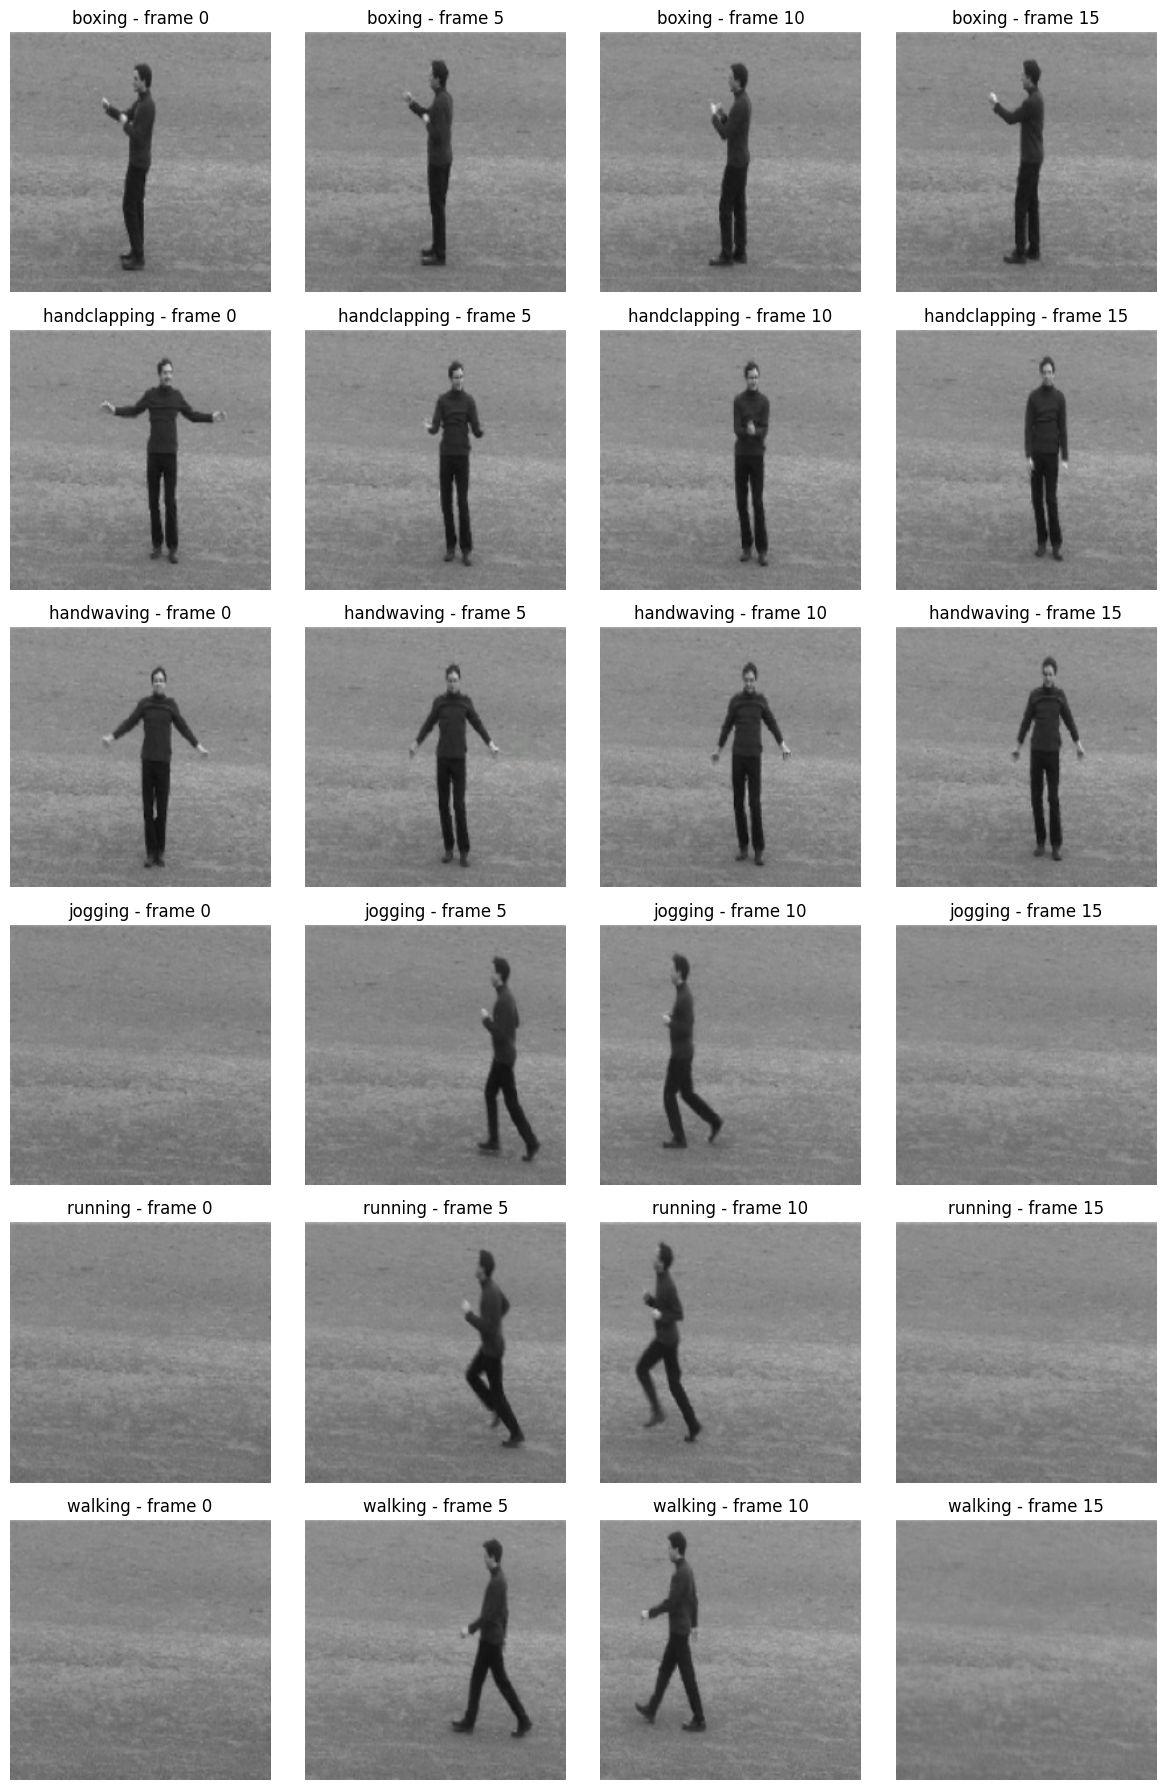

In [ ]:
### YOUR CODE STARTS HERE ###
# One sample clip from each class; show temporal positions 0, 5, 10, 15.
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 18))
for r, cls in enumerate(CLASSES):
    row = video_df[video_df['action']==cls].iloc[0]
    clip,_ = KTHClipDataset(pd.DataFrame([row]), frame_transform)[0]
    for j, t in enumerate([0,5,10,15]):
        img = clip[t].permute(1,2,0).numpy(); img = img*np.array([0.229,0.224,0.225])+np.array([0.485,0.456,0.406]); img=np.clip(img,0,1)
        axes[r,j].imshow(img); axes[r,j].axis('off'); axes[r,j].set_title(f'{cls} - frame {t}')
plt.tight_layout(); plt.show()


### YOUR CODE ENDS HERE ###


### 3.3 Action Class Distribution Analysis (Q15) [3 Marks]

Q15: Analyze and plot the action class distribution across Train/Val/Test splits.

**Steps:**
1. Aggregate sequence counts:
   ```python
   counts = video_df.groupby(['split', 'action']).size().unstack(fill_value=0)
                    .reindex(index=['train', 'val', 'test'], columns=CLASSES)
   ```
2. Plot a **grouped bar chart** showing sequence clips per action class, grouped by split.
3. Plot a **bar chart** of total sequence clips per split with exact count annotations on each bar.
4. Display the underlying counts table using `display()`.


split         test  train  val
action                        
boxing          79    254   64
handclapping    80    252   64
handwaving      80    254   64
jogging         80    256   64
running         80    256   64
walking         80    256   64


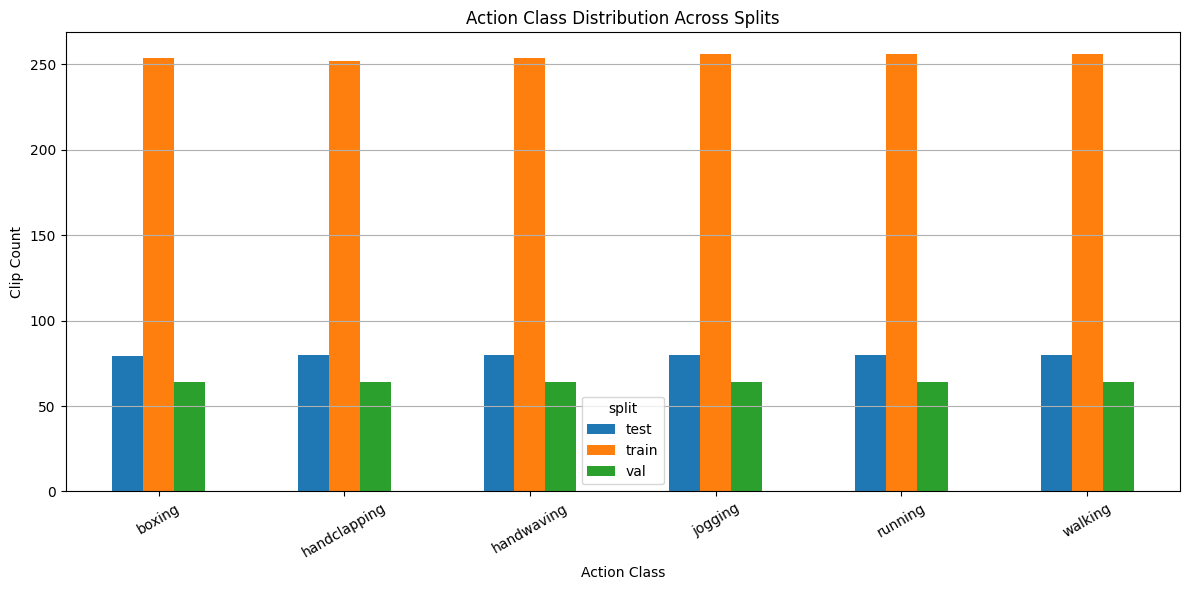

In [ ]:
### YOUR CODE STARTS HERE ###

counts = pd.crosstab(video_df['action'], video_df['split']).reindex(CLASSES).fillna(0)
print(counts)
ax = counts.plot(kind='bar', figsize=(12,6)); ax.set_xlabel('Action Class'); ax.set_ylabel('Clip Count'); ax.set_title('Action Class Distribution Across Splits'); ax.grid(axis='y'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


### YOUR CODE ENDS HERE ###


## Task 4: Spatial Feature Extractor & Recurrent Models [14 Marks]


### 4.1 Frozen Spatial Feature Extractor - `FrozenResNet18` (Q16) [4 Marks]

Q16: Define a permanently frozen ResNet-18 feature extractor. Maps `(B, 16, 3, 224, 224)` → `(B, 16, 512)`.

- `__init__()`: Load `models.resnet18(weights=ResNet18_Weights.DEFAULT)`, replace `fc` with `nn.Identity()`, freeze all parameters (`p.requires_grad = False`), and call `self.eval()` so all submodules (including BatchNorm) enter evaluation mode.
- `train(mode=True)`: Override to ensure the extractor always remains in eval mode (`return super().train(False)`).
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → `backbone` → reshape to `(B, T, 512)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class FrozenResNet18(nn.Module):
    """
    ImageNet-pretrained ResNet-18 without its linear head; all parameters frozen.
    Maps (B, 16, 3, 224, 224) -> (B, 16, 512).
    """
    def __init__(self):
        super().__init__()
        # TODO: 1. Load models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        #       2. Replace backbone.fc with nn.Identity()
        #       3. Freeze every backbone parameter (requires_grad = False)
        #       4. Call self.eval() so all submodules (including BatchNorm) start in eval mode
        pass

    def train(self, mode=True):
        # TODO: Override so the module always stays in eval mode: return super().train(False)
        pass

    def forward(self, clips):
        # TODO: Flatten (B, T, C, H, W) -> (B*T, C, H, W), run through self.backbone,
        #       reshape the result back to (B, T, FEATURE_DIM)
        pass

# TODO: Verify the output shape and that no parameters are trainable, on a dummy
#       (2, CLIP_LEN, 3, IMAGE_SIZE, IMAGE_SIZE) input.
extractor=FrozenResNet18().to(DEVICE)
dummy=torch.randn(2,CLIP_LEN,3,IMAGE_SIZE,IMAGE_SIZE,device=DEVICE)
with torch.no_grad(): out=extractor(dummy)
print('Output shape:', out.shape); print('Trainable params:', sum(p.requires_grad for p in extractor.parameters()))
del dummy, out
### YOUR CODE ENDS HERE ###


AttributeError: 'NoneType' object has no attribute 'shape'

### 4.2 Recurrent Head Architecture `RecurrentHead` (Q17) [10 Marks]

Q17: Design a modular `RecurrentHead(nn.Module)` supporting RNN and LSTM with configurable directionality.

**Constructor arguments:** `(recurrent_type, bidirectional, input_size=512, hidden_size=64, num_layers=1, num_classes=6, dropout=0.3)`
- `recurrent_type`: `'rnn'` or `'lstm'` (`nn.RNN` or `nn.LSTM` with `batch_first=True`, `bidirectional=bidirectional`)
- Temporal pooling uses the last timestep. For unidirectional, take `outputs[:, -1, :]`. For bidirectional, concatenate the forward last timestep (`outputs[:, -1, :hidden_size]`) with the backward last timestep (`outputs[:, 0, hidden_size:]`).
- `dropout`: `nn.Dropout(dropout)` applied before the linear classifier.
- `classifier`: `nn.Linear(classifier_input_dim, num_classes)`.
  - `classifier_input_dim = hidden_size * (2 if bidirectional else 1)`

**Forward pass:** `features` `(B, 16, 512)` -> recurrent layer -> pool temporal dimension -> dropout -> classifier -> return raw logits `(B, 6)`.

**Helper functions provided:**
- `count_parameters(model)`: Returns `(total_params, trainable_params)`.
- `get_submodule_parameter_breakdown(model)`: Returns per-submodule parameter breakdown table.

**Task:** Instantiate the 4 core configurations and display their parameter summaries. `STAGE1_CORE_CONFIGS` is provided in the code cell below; Q21 and Q23 index it by these exact keys, so do not rename them.

| Config key | `recurrent_type` | `bidirectional` |
|---|---|---|
| `rnn_uni` | `'rnn'` | `False` |
| `rnn_bi` | `'rnn'` | `True` |
| `lstm_uni` | `'lstm'` | `False` |
| `lstm_bi` | `'lstm'` | `True` |


In [ ]:
### YOUR CODE STARTS HERE ###

class RecurrentHead(nn.Module):
    def __init__(self, recurrent_type, bidirectional,
                 input_size=FEATURE_DIM, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
                 dropout=DROPOUT):
        super().__init__()
        # TODO: 1. Validate recurrent_type ('rnn' or 'lstm')
        # TODO: 2. Instantiate self.recurrent (nn.RNN or nn.LSTM with batch_first=True)
        # TODO: 3. output_dim = hidden_size * (2 if bidirectional else 1)
        # TODO: 4. self.dropout = nn.Dropout(dropout)
        # TODO: 5. self.classifier = nn.Linear(output_dim, num_classes)
        pass

    def forward(self, features):
        # TODO: 1. Run features through self.recurrent: outputs, _ = self.recurrent(features)
        # TODO: 2. Pool the temporal dimension using the last timestep
        #          - If bidirectional: cat forward last & backward first
        #          - If unidirectional: take the last timestep
        # TODO: 3. Apply dropout and linear classifier, return logits
        pass


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def get_submodule_parameter_breakdown(model, model_name=""):
    rows = []
    for name, module in model.named_children():
        n_params = sum(p.numel() for p in module.parameters())
        n_train = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append({
            "Submodule": name,
            "Type": module.__class__.__name__,
            "Total Parameters": f"{n_params:,}",
            "Trainable": f"{n_train:,}",
            "Frozen": f"{n_params - n_train:,}",
        })
    total, trainable = count_parameters(model)
    rows.append({
        "Submodule": "Total",
        "Type": model.__class__.__name__,
        "Total Parameters": f"{total:,}",
        "Trainable": f"{trainable:,}",
        "Frozen": f"{total - trainable:,}",
    })
    return pd.DataFrame(rows)


STAGE1_CORE_CONFIGS = {
    "rnn_uni":  {"recurrent_type": "rnn",  "bidirectional": False},
    "rnn_bi":   {"recurrent_type": "rnn",  "bidirectional": True},
    "lstm_uni": {"recurrent_type": "lstm", "bidirectional": False},
    "lstm_bi":  {"recurrent_type": "lstm", "bidirectional": True},
}

# TODO: Instantiate each head and display a parameter breakdown table for all 4 models.
for name,config in STAGE1_CORE_CONFIGS.items():
    h=RecurrentHead(**config); print('\n',name); display(get_submodule_parameter_breakdown(h,name))
### YOUR CODE ENDS HERE ###



 rnn_uni


,Submodule,Type,Total Parameters,Trainable,Frozen
0,Total,RecurrentHead,0,0,0



 rnn_bi


,Submodule,Type,Total Parameters,Trainable,Frozen
0,Total,RecurrentHead,0,0,0



 lstm_uni


,Submodule,Type,Total Parameters,Trainable,Frozen
0,Total,RecurrentHead,0,0,0



 lstm_bi


,Submodule,Type,Total Parameters,Trainable,Frozen
0,Total,RecurrentHead,0,0,0


## Task 5: Stage-1 Recurrent Model Training & Evaluation [17 Marks]


### 5.1 Extracting and Saving Features to Disk (Q18) [2 Marks]

Q18: Precompute spatial features using `FrozenResNet18` and save them to disk for fast Stage-1 training.

**Provided below:**
- Full implementation of `extract_features(dataset, backbone, batch_size=16, desc=...)`
- `FrozenResNet18` extractor instantiation
- Complete feature extraction, disk saving (`torch.save((train_features, train_labels), FEATURE_DIR / "train_features.pt")`), and `stage1_train_loader` setup for the **train** split

**Tasks to complete:**
1. Extract and save features for **validation** (`val_features.pt`) and **test** (`test_features.pt`) splits to `FEATURE_DIR`.
2. Free the extractor from memory: `del extractor` + `gc.collect()` + `torch.cuda.empty_cache()`.
3. Construct `stage1_val_loader` and `stage1_test_loader` over `TensorDataset(features, labels)` with `batch_size=STAGE1_BATCH_SIZE` (`shuffle=False`, `num_workers=NUM_WORKERS`, `pin_memory=(DEVICE.type == "cuda")`).
4. Verify with the provided assertions that files are saved and DataLoaders are created.

**Expected tensor shapes:** Train `(1528, 16, 512)`, Val `(384, 16, 512)`, Test `(479, 16, 512)`.


In [ ]:
### YOUR CODE STARTS HERE ###

@torch.no_grad()
def extract_features(dataset, backbone, batch_size=16, desc="Extracting features"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
    feature_batches, label_batches = [], []
    total_batches = len(loader)

    for i, (clips, labels) in enumerate(loader, 1):
        clips = clips.to(DEVICE, non_blocking=True)
        features = backbone(clips)
        feature_batches.append(features.cpu())
        label_batches.append(labels.clone())
        if i % 15 == 0 or i == total_batches:
            print(f"  [{desc}] Batch [{i:02d}/{total_batches:02d}] extracted")

    return (torch.cat(feature_batches, dim=0),
            torch.cat(label_batches, dim=0))


extractor = FrozenResNet18().to(DEVICE)

print("Starting spatial feature precomputation with FrozenResNet18...")

# --- Provided: Train split feature extraction, disk saving, and DataLoader ---
train_features, train_labels = extract_features(train_dataset, extractor, desc="Train Features")
torch.save((train_features, train_labels), FEATURE_DIR / "train_features.pt")
print(f"  train: {train_features.shape}, labels: {train_labels.shape}")

stage1_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=STAGE1_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

# TODO: 1. Extract and save val_features, val_labels to FEATURE_DIR / "val_features.pt"
# TODO: 2. Extract and save test_features, test_labels to FEATURE_DIR / "test_features.pt"
# TODO: 3. Free extractor memory (del extractor, gc.collect(), torch.cuda.empty_cache() if GPU available)
# TODO: 4. Construct stage1_val_loader and stage1_test_loader (batch_size=STAGE1_BATCH_SIZE, shuffle=False)

# Assertions
assert 'val_features' in locals() and 'val_labels' in locals(), "val_features and val_labels must be defined."
assert 'test_features' in locals() and 'test_labels' in locals(), "test_features and test_labels must be defined."
assert (FEATURE_DIR / "val_features.pt").exists() and (FEATURE_DIR / "test_features.pt").exists(), "val_features.pt and test_features.pt must be saved to disk."
assert 'stage1_val_loader' in locals() and 'stage1_test_loader' in locals(), "stage1_val_loader and stage1_test_loader must be defined."
assert len(stage1_val_loader) > 0 and len(stage1_test_loader) > 0, "DataLoaders must not be empty."

print(f"Features saved to {FEATURE_DIR}:")
print(f"  train: {train_features.shape}, labels: {train_labels.shape}")
print(f"  val:   {val_features.shape}, labels: {val_labels.shape}")
print(f"  test:  {test_features.shape}, labels: {test_labels.shape}")

### YOUR CODE ENDS HERE ###


### 5.2 Evaluation Function - `evaluate_classification_model` (Q19) [2 Marks]

Q19: Implement `evaluate_classification_model` - evaluates a model on a given DataLoader.

**Signature:** `evaluate_classification_model(model, data_loader, criterion=None)`

**Steps:**
1. Decorate with `@torch.no_grad()`, set `model.eval()`. If `criterion is None`, default to `nn.CrossEntropyLoss()`.
2. Loop through batches, compute average cross-entropy loss and accuracy.
3. Collect predictions and ground truth labels as numpy arrays.
4. Return `(loss, accuracy, predictions_numpy, ground_truth_numpy)`.


In [ ]:
### YOUR CODE STARTS HERE ###

@torch.no_grad()
def evaluate_classification_model(model, data_loader, criterion=None):
    # TODO: 1. If criterion is None, default to nn.CrossEntropyLoss()
    # TODO: 2. Set model.eval(), loop batches, compute total loss and accuracy
    # TODO: 3. Collect predictions and ground truth as numpy arrays
    # TODO: 4. Return (loss, accuracy, predictions_numpy, ground_truth_numpy)
    pass

### YOUR CODE ENDS HERE ###


### 5.3 Training Function - `train_classification_model` (Q20) [4 Marks]

Q20: Implement `train_classification_model` - a complete training loop with gradient accumulation, early stopping, and model checkpointing.

**Signature:** `train_classification_model(model, train_loader, val_loader, max_epochs, learning_rate, checkpoint_path=None, model_name="", accumulation_steps=1, patience=EARLY_STOPPING_PATIENCE, min_delta=1e-4, print_interval=10)`

> **Checkpoint criterion:** Highest validation accuracy (saves model weights whenever validation accuracy improves).  
> **Early-stopping criterion:** Lowest validation loss (triggers early stopping if validation loss fails to decrease by at least `min_delta=1e-4` for `patience=5` consecutive epochs).

**Steps:**
1. Initialize optimizer: `optim.Adam(trainable_params, lr=learning_rate, weight_decay=WEIGHT_DECAY)`.
2. Initialize criterion: `nn.CrossEntropyLoss()`.
3. Loop epochs 1 to `max_epochs`:
   - **Training phase** (`model.train()`): Loop batches with gradient accumulation (`loss / accumulation_steps`), apply gradient clipping via `nn.utils.clip_grad_norm_(trainable_params, max_norm=GRADIENT_CLIP_NORM)`. Step optimizer and zero gradients every `accumulation_steps` batches or on the final batch of the epoch.
   - **Validation phase**: Call `evaluate_classification_model()` on `val_loader`.
   - Print progress every `print_interval` epochs.
   - **Checkpoint:** Save `model.state_dict()` via `torch.save()` if validation accuracy improves.
   - **Early stopping:** Stop if validation loss doesn't improve by at least `min_delta=1e-4` for `patience` (5) consecutive epochs.
4. Return `(history_df, summary_dict)` with the following outputs:
   - **`history_df` (pandas DataFrame)** containing per-epoch metric tracking: `epoch`, `train_loss`, `train_accuracy`, `val_loss`, `val_accuracy`.
   - **`summary_dict` (Python dictionary)** containing overall run statistics: `total_parameters`, `trainable_parameters`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `seconds`.


In [ ]:
### YOUR CODE STARTS HERE ###

def train_classification_model(model, train_loader, val_loader, max_epochs, learning_rate, checkpoint_path=None,
                model_name="", accumulation_steps=1, patience=EARLY_STOPPING_PATIENCE,
                min_delta=1e-4, print_interval=10):
    """
    Complete training loop with gradient accumulation, early stopping, and checkpointing.
    """
    # TODO: 1. Initialize optimizer (Adam with weight_decay=WEIGHT_DECAY) and criterion (CrossEntropyLoss)
    # TODO: 2. Loop epochs 1 to max_epochs:
    #          a. model.train() - loop batches with gradient accumulation,
    #             gradient clipping (max_norm=GRADIENT_CLIP_NORM), optimizer step every accumulation_steps batches or on final batch
    #          b. Call evaluate_classification_model() on val_loader
    #          c. Print progress every print_interval epochs
    #          d. Checkpoint model if val_accuracy improves
    #          e. Early stop if val_loss doesn't improve by at least min_delta for patience epochs
    # TODO: 3. Return (history_DataFrame, summary_dict)
    pass

### YOUR CODE ENDS HERE ###


### 5.4 Training the 4 Core Recurrent Models (Q21) [5 Marks]

Q21: Train the 4 core recurrent model configurations on precomputed features and compare results.

**Steps:**
1. Iterate over `STAGE1_CORE_CONFIGS` (`rnn_uni`, `rnn_bi`, `lstm_uni`, `lstm_bi`).
2. For each config:
   - Call `set_seed(SEED)` **before instantiating the model**, so all four architectures start from the same initialization.
   - Instantiate `RecurrentHead(**config).to(DEVICE)`.
   - Call `train_classification_model()` with `stage1_train_loader`, `stage1_val_loader`, `max_epochs=STAGE1_MAX_EPOCHS` (50), `learning_rate=STAGE1_LR` (1e-3), `patience=5`.
   - Save best checkpoints as `stage1_{name}_best_acc.pt` in `MODEL_DIR`.
   - Store training histories in `stage1_histories` dict and run summaries in `stage1_results` list.
3. Compile all model summaries into `stage1_results_df` and display it sorted by `best_val_accuracy` (descending) to compare all trained models.

**Required `stage1_results_df` columns** - later questions index these by name, so use them exactly:
`model_name`, `recurrent_type`, `bidirectional`, `hidden_dim`, `trainable_params`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `seconds`

**Required `stage1_histories` shape:** a dict keyed by model name, each value the `history_df` returned by `train_classification_model()`.


In [ ]:
### YOUR CODE STARTS HERE ###

stage1_histories={}; stage1_results=[]
for name,config in STAGE1_CORE_CONFIGS.items():
    set_seed(SEED); model=RecurrentHead(**config).to(DEVICE); ckpt=MODEL_DIR/f'stage1_{name}_best_acc.pt'
    hist,summary=train_classification_model(model,stage1_train_loader,stage1_val_loader,STAGE1_MAX_EPOCHS,STAGE1_LR,checkpoint_path=ckpt,model_name=name,accumulation_steps=1,patience=5)
    stage1_histories[name]=hist; stage1_results.append({'model_name':name,**config,'hidden_dim':HIDDEN_SIZE,'trainable_params':summary['trainable_parameters'],'best_val_accuracy':summary['best_val_accuracy'],'best_val_accuracy_epoch':summary['best_val_accuracy_epoch'],'best_val_loss':summary['best_val_loss'],'best_val_loss_epoch':summary['best_val_loss_epoch'],'epochs_run':summary['epochs_run'],'seconds':summary['seconds']})
stage1_results_df=pd.DataFrame(stage1_results).sort_values('best_val_accuracy',ascending=False).reset_index(drop=True); display(stage1_results_df)


### YOUR CODE ENDS HERE ###


NameError: name 'train_classification_model' is not defined

### 5.5 Stage-1 Results Summary & Loss Convergence Curves (Q22) [2 Marks]

Q22: Display the Stage-1 results table for all trained models and plot loss convergence curves.

**Steps:**
1. Display `stage1_results_df` comparing performance across all 4 trained recurrent models.
2. Create a `2×2` subplot grid (`figsize=(12, 9)`, `sharey=True`).
3. For each of the 4 models, plot **Training Loss** and **Validation Loss** vs Epoch on its own subplot.
4. Add subplot titles (model name), axis labels, legends (`'Train Loss'`, `'Val Loss'`), and grid lines.
5. `plt.tight_layout()` and `plt.show()`.


In [ ]:
### YOUR CODE STARTS HERE ###
display(stage1_results_df)
fig,axes=plt.subplots(2,2,figsize=(12,9),sharey=True)
for ax,(name,hist) in zip(axes.ravel(),stage1_histories.items()):
    ax.plot(hist['epoch'],hist['train_loss'],label='Train Loss'); ax.plot(hist['epoch'],hist['val_loss'],label='Val Loss'); ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


### YOUR CODE ENDS HERE ###


NameError: name 'stage1_results_df' is not defined

### 5.6 Test Evaluation & Confusion Matrix for the Best Model (Q23) [2 Marks]

Q23: Evaluate the winning Stage-1 model on the test set and display its confusion matrix.

**Function `plot_confusion_matrix(targets, predictions, title)`:**
1. Build a `NUM_CLASSES × NUM_CLASSES` count matrix from `(targets, predictions)` pairs.
2. Plot with `plt.imshow()` using `cmap='Blues'`, annotating each cell with its count and row-normalized percentage.
3. Label axes with `CLASSES`, add colorbar and title.
4. Return a per-class DataFrame with support and recall.

**Then:**
1. Identify `best_stage1_name` from `stage1_results_df` (row 0, already sorted by val accuracy).
2. Store its config as `best_stage1_config` (looked up in `STAGE1_CORE_CONFIGS`) and its checkpoint path as `best_stage1_checkpoint` (in `MODEL_DIR`). Q27 reuses both under these names.
3. Rebuild `RecurrentHead(**config)`, load the checkpoint `state_dict` via `torch.load()`, move to `DEVICE`.
4. Evaluate on `stage1_test_loader` using `evaluate_classification_model()`, storing the results as `test_loss_s1, test_acc_s1, test_preds_s1, test_targets_s1` — **Q30 reuses `test_acc_s1` and `test_loss_s1`**.
5. Print Test metrics (accuracy, loss, macro/weighted precision via `sklearn.metrics.precision_score`) and display the confusion matrix.


In [ ]:
### YOUR CODE STARTS HERE ###

def plot_confusion_matrix(targets, predictions, title):
    # TODO: 1. Build a NUM_CLASSES x NUM_CLASSES count matrix from (targets, predictions) pairs
    #       2. Plot it with imshow, annotating each cell with its count and row-normalized percentage
    #       3. Label axes with CLASSES, add a colorbar and title; plt.tight_layout(), plt.show()
    #       4. Return a per-class DataFrame with support and recall
    pass

# TODO: 1. Identify best_stage1_name from stage1_results_df (row 0, already sorted by val accuracy)
#       2. Store best_stage1_config (from STAGE1_CORE_CONFIGS) and best_stage1_checkpoint
#          (in MODEL_DIR) - Q27 reuses both under these names
#       3. Rebuild RecurrentHead(**config), load the checkpoint state_dict, move it to DEVICE
#       4. Evaluate on stage1_test_loader using evaluate_classification_model (loss, accuracy, predictions, targets)
#       5. Print Test metrics (accuracy, macro/weighted precision, loss) and display the confusion matrix via plot_confusion_matrix

### YOUR CODE ENDS HERE ###


## Task 6: Stage-2 End-to-End CNN Fine-Tuning & Model Comparison [20 Marks]


### 6.1 Custom CNN Backbone - `CustomCNN` (Q24) [3 Marks]

Q24: Define a custom 4-block CNN backbone `CustomCNN` trained from scratch.

**Architecture** (applied per-frame, output reshaped to `(B, T, 512)`):

| Block | Layers | Output channels |
|---|---|---|
| 1 | `Conv2d(3, 64, k=3, p=1)` → `BatchNorm2d(64)` → `ReLU` → `MaxPool2d(2)` | 64 |
| 2 | `Conv2d(64, 128, k=3, p=1)` → `BatchNorm2d(128)` → `ReLU` → `MaxPool2d(2)` | 128 |
| 3 | `Conv2d(128, 256, k=3, p=1)` → `BatchNorm2d(256)` → `ReLU` → `MaxPool2d(2)` | 256 |
| 4 | `Conv2d(256, 512, k=3, p=1)` → `BatchNorm2d(512)` → `ReLU` (no pool) | 512 |

Followed by `AdaptiveAvgPool2d((1, 1))` and `Linear(512, output_dim)` projection.

- `set_trainable(mode='full')`: Always marks every parameter trainable (CustomCNN is trained from scratch).
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → conv blocks → pool → flatten → projection → reshape to `(B, T, output_dim)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class CustomCNN(nn.Module):
    """
    Small CNN trained from scratch: 4 Conv-BatchNorm-ReLU(-MaxPool) blocks,
    global average pool, and a linear projection to FEATURE_DIM.
    """
    def __init__(self, output_dim=FEATURE_DIM):
        super().__init__()
        # TODO: Build 4 conv blocks as described in the architecture table above
        # TODO: self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # TODO: self.projection = nn.Linear(512, output_dim)
        pass

    def set_trainable(self, mode="full"):
        # CustomCNN is trained from scratch; all parameters are always trainable.
        # TODO: Mark every parameter trainable (requires_grad = True)
        pass

    def forward(self, clip):
        # TODO: Flatten (B, T, C, H, W) -> (B*T, C, H, W), conv blocks,
        #       pool + flatten + projection, reshape to (B, T, output_dim)
        pass

### YOUR CODE ENDS HERE ###


### 6.2 Pretrained ResNet-18 Backbone - `ResNetCNN` (Q25) [4 Marks]

Q25: Define a pretrained ResNet-18 backbone with selective residual-block unfreezing.

- `__init__()`: Load `models.resnet18(weights=ResNet18_Weights.DEFAULT)`, replace `fc` with `nn.Identity()`. Store `output_dim = FEATURE_DIM` (512).
- `set_trainable(mode)`: First freeze ALL backbone parameters. Then based on `mode`:
  - `'block4'`: unfreeze residual block 4 (`backbone.layer4`) only
  - `'block3_4'`: unfreeze residual blocks 3 and 4 (`backbone.layer3` and `backbone.layer4`)
  - `'full'`: unfreeze the entire backbone
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → `self.backbone` → reshape to `(B, T, output_dim)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class ResNetCNN(nn.Module):
    """
    ImageNet ResNet-18 with selectable trainable depth:
    'block4', 'block3_4', or 'full'.
    """
    def __init__(self):
        super().__init__()
        # TODO: Load models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # TODO: Replace backbone.fc with nn.Identity()
        # TODO: Set self.output_dim = FEATURE_DIM
        pass

    def set_trainable(self, mode):
        # TODO: 1. Freeze every backbone parameter first
        # TODO: 2. Based on mode ('block4' / 'block3_4' / 'full'), selectively unfreeze
        pass

    def forward(self, clip):
        # TODO: Flatten (B, T, C, H, W) -> (B*T, C, H, W), backbone, reshape to (B, T, output_dim)
        pass

### YOUR CODE ENDS HERE ###


### 6.3 Combined End-to-End Model - `Stage2Model` (Q26) [3 Marks]

Q26: Combine a CNN backbone with `RecurrentHead` into an end-to-end fine-tunable model.

- `__init__(self, cnn, head)`: Store `cnn` and `head` as submodules.
- `train(self, mode=True)`: Call `super().train(mode)`. If entering train mode, force any `BatchNorm` module whose parameters are **all frozen** back into `eval()` so running stats don't update.
- `forward(self, clip)`: `self.cnn(clip)` → `self.head(features)` → return logits.

**Verification:** Build `Stage2Model` with `ResNetCNN` for each mode (`'block4'`, `'block3_4'`, `'full'`) and display trainable vs frozen parameter breakdowns using `get_submodule_parameter_breakdown()`.


In [ ]:
### YOUR CODE STARTS HERE ###

class Stage2Model(nn.Module):
    """CNN front-end + transferred RecurrentHead, fine-tuned end-to-end."""

    def __init__(self, cnn, head):
        super().__init__()
        # TODO: Store cnn and head as attributes
        pass

    def train(self, mode=True):
        # TODO: Call super().train(mode); if entering train mode, force frozen BatchNorm
        #       modules back into eval() so their running stats don't update
        pass

    def forward(self, clip):
        # TODO: Run clip through self.cnn, then self.head, return logits
        pass

# TODO: Sanity-check: build Stage2Model with ResNetCNN for each of
#       'block4' / 'block3_4' / 'full', display trainable-vs-frozen parameter breakdown

### YOUR CODE ENDS HERE ###


### 6.4 Fine-Tuning with Pretrained Weights (Q27) [4 Marks]

Q27: Warm-start Stage-2 models from the winning Stage-1 head weights and fine-tune end-to-end.

**Implement `build_stage2_model(cnn_kind, cnn_mode, head_state_dict, head_config=None)`:**
1. Build `CustomCNN()` or `ResNetCNN()` based on `cnn_kind`.
2. Instantiate a fresh `RecurrentHead` matching the winning Stage-1 config (`head_config` or `best_stage1_config`).
3. Load pretrained head weights: `head.load_state_dict(head_state_dict)` - keep the head **trainable** (not frozen) so it adapts alongside the CNN.
4. Wrap in `Stage2Model(cnn, head)` and call `cnn.set_trainable(cnn_mode)`.
5. Return the assembled `Stage2Model`.

**4 Stage-2 configurations (`STAGE2_CONFIGS`):**

| Name | `cnn_kind` | `cnn_mode` |
|---|---|---|
| `custom_cnn` | `'custom'` | `'full'` |
| `resnet18_block4` | `'resnet'` | `'block4'` |
| `resnet18_block3_4` | `'resnet'` | `'block3_4'` |
| `resnet18_full` | `'resnet'` | `'full'` |

**Training hyperparameters:**
- `max_epochs = STAGE2_MAX_EPOCHS` (50)
- `learning_rate = STAGE2_LR` (1e-4)
- `batch_size = STAGE2_BATCH_SIZE` (4)
- `accumulation_steps = STAGE2_GRAD_ACCUMULATION` (4) → effective batch size = 16
- `patience = 5`

For each configuration, call `set_seed(SEED)` **before building the model**, then train using `train_classification_model()`, save best checkpoints as `stage2_{name}_best_acc.pt`, store histories in `stage2_histories`, and compile/display `stage2_results_df` sorted by `best_val_accuracy` (descending).

**Required `stage2_results_df` columns** - later questions index these by name, so use them exactly:
`model_name`, `trainable_cnn_part`, `hidden_dim`, `total_params_m`, `trainable_params_m`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `minutes`

**Required `stage2_histories` shape:** a dict keyed by model name, each value the `history_df` returned by `train_classification_model()`.

In [ ]:
### YOUR CODE STARTS HERE ###

STAGE2_CONFIGS={'custom_cnn':('custom','full'),'resnet18_block4':('resnet','block4'),'resnet18_block3_4':('resnet','block3_4'),'resnet18_full':('resnet','full')}
def build_stage2_model(cnn_kind,cnn_mode,head_state_dict,head_config=None):
    cnn=CustomCNN() if cnn_kind=='custom' else ResNetCNN(); config=head_config or best_stage1_config; head=RecurrentHead(**config); head.load_state_dict(head_state_dict); model=Stage2Model(cnn,head).to(DEVICE); cnn.set_trainable(cnn_mode); return model

stage2_histories={}; stage2_results=[]
head_state=torch.load(best_stage1_checkpoint,map_location='cpu')
for name,(kind,mode) in STAGE2_CONFIGS.items():
    set_seed(SEED); model=build_stage2_model(kind,mode,head_state,best_stage1_config); ckpt=MODEL_DIR/f'stage2_{name}_best_acc.pt'
    hist,summary=train_classification_model(model,stage2_train_loader,stage2_val_loader,STAGE2_MAX_EPOCHS,STAGE2_LR,checkpoint_path=ckpt,model_name=name,accumulation_steps=STAGE2_GRAD_ACCUMULATION,patience=5)
    stage2_histories[name]=hist; stage2_results.append({'model_name':name,'trainable_cnn_part':mode,'hidden_dim':HIDDEN_SIZE,'total_params_m':summary['total_parameters']/1e6,'trainable_params_m':summary['trainable_parameters']/1e6,'best_val_accuracy':summary['best_val_accuracy'],'best_val_accuracy_epoch':summary['best_val_accuracy_epoch'],'best_val_loss':summary['best_val_loss'],'best_val_loss_epoch':summary['best_val_loss_epoch'],'epochs_run':summary['epochs_run'],'minutes':summary['seconds']/60})
stage2_results_df=pd.DataFrame(stage2_results).sort_values('best_val_accuracy',ascending=False).reset_index(drop=True); display(stage2_results_df)


### YOUR CODE ENDS HERE ###


NameError: name 'best_stage1_checkpoint' is not defined

### 6.5 Stage-2 Results & Learning Curves (Q28) [2 Marks]

Q28: Display the Stage-2 results table for all fine-tuned models and plot loss convergence curves.

**Steps:**
1. Display `stage2_results_df` comparing all 4 fine-tuned Stage-2 models.
2. Create a `2×2` subplot grid (`figsize=(12, 9)`, `sharey=True`).
3. For each of the 4 Stage-2 models, plot **Training Loss** and **Validation Loss** vs Epoch.
4. Add subplot titles, axis labels, legends, and grid. `plt.tight_layout()` and `plt.show()`.


In [ ]:
### YOUR CODE STARTS HERE ###

display(stage2_results_df)
fig,axes=plt.subplots(2,2,figsize=(12,9),sharey=True)
for ax,(name,hist) in zip(axes.ravel(),stage2_histories.items()):
    ax.plot(hist['epoch'],hist['train_loss'],label='Training Loss'); ax.plot(hist['epoch'],hist['val_loss'],label='Validation Loss'); ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


### YOUR CODE ENDS HERE ###


NameError: name 'stage2_results_df' is not defined

### 6.6 Test Evaluation & Confusion Matrix for the Best Model (Q29) [2 Marks]

Q29: Evaluate the best Stage-2 model on the held-out test set and display its confusion matrix.

**Steps:**
1. Identify `best_stage2_name` from `stage2_results_df` (row 0, already sorted by val accuracy).
2. Look up its `(cnn_kind, cnn_mode)` in `STAGE2_CONFIGS` and its checkpoint path in `MODEL_DIR`.
3. Rebuild the model via `build_stage2_model(...)`, load checkpoint `state_dict` via `torch.load()`, move to `DEVICE`.
4. Evaluate on `stage2_test_loader` using `evaluate_classification_model()`, storing the results as `test_loss_s2, test_acc_s2, test_preds_s2, test_targets_s2` — **Q30 reuses `test_acc_s2` and `test_loss_s2`**.
5. Print Test metrics (accuracy, loss, macro/weighted precision).
6. Display the `6×6` test confusion matrix via `plot_confusion_matrix()`.
7. Free memory: `del model` + `gc.collect()` + `torch.cuda.empty_cache()`.


In [ ]:
### YOUR CODE STARTS HERE ###

# TODO: 1. Identify best_stage2_name from stage2_results_df (row 0, already sorted by val accuracy)
# TODO: 2. Look up its (cnn_kind, cnn_mode) in STAGE2_CONFIGS and its checkpoint path in MODEL_DIR
# TODO: 3. Rebuild model via build_stage2_model(...), load checkpoint state_dict, move to DEVICE
# TODO: 4. Evaluate on stage2_test_loader using evaluate_classification_model() - get loss, accuracy, predictions, targets
# TODO: 5. Print Test metrics (accuracy, loss, macro/weighted precision)
# TODO: 6. Display 6x6 test confusion matrix via plot_confusion_matrix()
# TODO: 7. Free GPU memory (del winning_s2_model, gc.collect(), torch.cuda.empty_cache())

best_stage2_name=stage2_results_df.iloc[0]['model_name']; cnn_kind,cnn_mode=STAGE2_CONFIGS[best_stage2_name]; ckpt=MODEL_DIR/f'stage2_{best_stage2_name}_best_acc.pt'
winning_s2_model=build_stage2_model(cnn_kind,cnn_mode,torch.load(best_stage1_checkpoint,map_location='cpu'),best_stage1_config); winning_s2_model.load_state_dict(torch.load(ckpt,map_location=DEVICE)); winning_s2_model.to(DEVICE)
test_loss_s2,test_acc_s2,test_preds_s2,test_targets_s2=evaluate_classification_model(winning_s2_model,stage2_test_loader)
print('Stage-2 test accuracy:',test_acc_s2,'loss:',test_loss_s2); print('Macro precision:',precision_score(test_targets_s2,test_preds_s2,average='macro',zero_division=0)); print('Weighted precision:',precision_score(test_targets_s2,test_preds_s2,average='weighted',zero_division=0)); display(plot_confusion_matrix(test_targets_s2,test_preds_s2,f'Stage-2 Winner: {best_stage2_name}'))
del winning_s2_model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None


### YOUR CODE ENDS HERE ###


NameError: name 'stage2_results_df' is not defined

### 6.7 Final Summary Table & Model Comparison (Q30) [2 Marks]

Q30: Create a final summary table comparing Stage-1 winner vs Stage-2 winner.

**Steps:**
1. Build a `pd.DataFrame` with 2 rows (Stage-1 winner, Stage-2 winner) and columns:
   - `Stage`, `Model Name`, `Selection Criterion` (validation accuracy), `Validation Accuracy`, `Test Accuracy`, `Test Loss`
2. Display the summary table.
3. Compute test accuracy improvement in percentage points:
   ```python
   improvement = (test_acc_s2 - test_acc_s1) * 100
   ```
4. Print a one-line conclusion stating whether fine-tuning the CNN improved or hurt test accuracy, and by how many percentage points.


In [ ]:
### YOUR CODE STARTS HERE ###

# TODO: 1. Build a pd.DataFrame with 2 rows (Stage-1 winner, Stage-2 winner) and columns:
#          ['Stage', 'Model Name', 'Selection Criterion', 'Validation Accuracy', 'Test Accuracy', 'Test Loss']
# TODO: 2. Display the summary table
# TODO: 3. Compute improvement = (test_acc_s2 - test_acc_s1) * 100 and print conclusion
final_summary=pd.DataFrame([{'Stage':'Stage-1','Model Name':best_stage1_name,'Selection Criterion':'Validation Accuracy','Validation Accuracy':stage1_results_df.iloc[0]['best_val_accuracy'],'Test Accuracy':test_acc_s1,'Test Loss':test_loss_s1},{'Stage':'Stage-2','Model Name':best_stage2_name,'Selection Criterion':'Validation Accuracy','Validation Accuracy':stage2_results_df.iloc[0]['best_val_accuracy'],'Test Accuracy':test_acc_s2,'Test Loss':test_loss_s2}])
display(final_summary)
improvement=(test_acc_s2-test_acc_s1)*100
direction='improved' if improvement>0 else 'hurt' if improvement<0 else 'did not change'
print(f'Fine-tuning {direction} test accuracy by {abs(improvement):.2f} percentage points.')

### YOUR CODE ENDS HERE ###


NameError: name 'best_stage1_name' is not defined